In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv("online_retail.csv")

In [7]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
print("Tozalashdan oldin:", df.shape)

df_clean = df.copy()
df_clean = df_clean.dropna(subset=["Description", "StockCode"])
df_clean = df_clean[df_clean["UnitPrice"] > 0]
df_clean = df_clean[df_clean["Quantity"] > 0]   
df_clean["StockCode"] = df_clean["StockCode"].astype(str).str.strip().str.upper()
df_clean["Description"] = df_clean["Description"].astype(str).str.strip()

print("Tozalashdan keyin:", df_clean.shape)
df_clean[["StockCode", "Description", "UnitPrice", "Quantity"]].head()

Tozalashdan oldin: (541909, 9)
Tozalashdan keyin: (530104, 9)


,StockCode,Description,UnitPrice,Quantity
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55,6
1,71053,WHITE METAL LANTERN,3.39,6
2,84406B,CREAM CUPID HEARTS COAT HANGER,2.75,8
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,6
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39,6


In [16]:
MIN_SAMPLES = 5
MIN_MARGIN_PCT = 0.15  

def compute_bounds(prices):
    q1 = prices.quantile(0.25)
    q3 = prices.quantile(0.75)
    iqr = q3 - q1
    median = prices.median()

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

 
    min_lower = median * (1 - MIN_MARGIN_PCT)
    min_upper = median * (1 + MIN_MARGIN_PCT)
    lower = max(0, min(lower, min_lower))
    upper = max(upper, min_upper)

    return pd.Series({
        "count": len(prices),
        "median_price": median,
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower_bound": lower, "upper_bound": upper
    })

product_stats = df_clean.groupby("StockCode")["UnitPrice"].apply(compute_bounds).unstack()

desc_map = df_clean.groupby("StockCode")["Description"].agg(lambda x: x.value_counts().index[0])
product_stats["Description"] = desc_map

global_stats = compute_bounds(df_clean["UnitPrice"])
print("Global narx chegaralari: {:.2f} - {:.2f}".format(global_stats["lower_bound"], global_stats["upper_bound"]))

product_stats.head(10)

Global narx chegaralari: 0.00 - 8.45


,count,median_price,q1,q3,iqr,lower_bound,upper_bound,Description
StockCode,,,,,,,,
10002,71.0,0.85,0.85,1.63,0.78,0.0000,2.8000,INFLATABLE POLITICAL GLOBE
10080,22.0,0.39,0.39,0.39,0.00,0.3315,0.4485,GROOVY CACTUS INFLATABLE
10120,30.0,0.21,0.21,0.21,0.00,0.1785,0.2415,DOGGY RUBBER
10123C,3.0,0.65,0.65,0.65,0.00,0.5525,0.7475,HEARTS WRAPPING TAPE
10124A,5.0,0.42,0.42,0.42,0.00,0.3570,0.4830,SPOTS ON RED BOOKCOVER TAPE
10124G,4.0,0.42,0.42,0.42,0.00,0.3570,0.4830,ARMY CAMO BOOKCOVER TAPE
10125,94.0,0.85,0.81,0.85,0.04,0.7225,0.9775,MINI FUNKY DESIGN TAPES
10133,198.0,0.79,0.42,0.83,0.41,0.0000,1.4450,COLOURING PENCILS BROWN TUBE
10135,179.0,1.25,1.25,1.28,0.03,1.0625,1.4375,COLOURING PENCILS BROWN TUBE


In [17]:
def check_price(stock_code, entered_price, product_stats=product_stats, global_stats=global_stats, verbose=True):
    """
    Mahsulot kodi va kiritilgan narxni tekshirib, anomaliya bor-yo'qligini aniqlaydi.

    Qaytaradi: dict -> status, message, lower_bound, upper_bound, median_price
    """
    stock_code = str(stock_code).strip().upper()

    if stock_code in product_stats.index and product_stats.loc[stock_code, "count"] >= MIN_SAMPLES:
        row = product_stats.loc[stock_code]
        lower, upper, median = row["lower_bound"], row["upper_bound"], row["median_price"]
        desc = row["Description"]
        source = "mahsulot tarixi"
    else:
        lower, upper, median = global_stats["lower_bound"], global_stats["upper_bound"], global_stats["median_price"]
        desc = "(noma'lum mahsulot yoki yetarli tarix yo'q)"
        source = "umumiy statistika (fallback)"

    if entered_price < lower:
        status = "LOW_ANOMALY"
        message = f"OGOHLANTIRISH: Narx juda PAST! Kiritilgan: {entered_price:.2f}, kutilgan minimal: {lower:.2f} (median: {median:.2f})"
    elif entered_price > upper:
        status = "HIGH_ANOMALY"
        message = f" OGOHLANTIRISH: Narx juda YUQORI! Kiritilgan: {entered_price:.2f}, kutilgan maksimal: {upper:.2f} (median: {median:.2f})"
    else:
        status = "NORMAL"
        message = f" Narx normal oraliqda ({lower:.2f} - {upper:.2f})"

    result = {
        "stock_code": stock_code, "description": desc, "entered_price": entered_price,
        "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
        "median_price": round(median, 2), "status": status, "message": message, "source": source
    }

    if verbose:
        print(f"Mahsulot: {desc}  [{stock_code}]  ({source})")
        print(message)

    return result

In [18]:
def interactive_check():
    stock_code = input("Mahsulot kodini (StockCode) kiriting: ").strip()
    try:
        entered_price = float(input("Narxni kiriting: ").strip())
    except ValueError:
        print(" Noto'g'ri narx formati!")
        return

    result = check_price(stock_code, entered_price, verbose=False)

    print()
    print("="*55)
    print(f"{'Mahsulot:':<22} {result['description']}")
    print(f"{'Kod:':<22} {result['stock_code']}")
    print("-"*55)
    print(f"{'Siz kiritgan narx:':<22} {result['entered_price']:.2f}")
    print(f"{'Odatiy (normal) narx:':<22} {result['median_price']:.2f}")
    print(f"{'Ruxsat etilgan oraliq:':<22} {result['lower_bound']:.2f} - {result['upper_bound']:.2f}")
    print("="*55)
    print(result["message"])
    print()

    return result

interactive_check()

Mahsulot kodini (StockCode) kiriting:  10002
Narxni kiriting:  21.0



Mahsulot:              INFLATABLE POLITICAL GLOBE
Kod:                   10002
-------------------------------------------------------
Siz kiritgan narx:     21.00
Odatiy (normal) narx:  0.85
Ruxsat etilgan oraliq: 0.00 - 2.80
 OGOHLANTIRISH: Narx juda YUQORI! Kiritilgan: 21.00, kutilgan maksimal: 2.80 (median: 0.85)



{'stock_code': '10002',
 'description': 'INFLATABLE POLITICAL GLOBE',
 'entered_price': 21.0,
 'lower_bound': np.float64(0.0),
 'upper_bound': np.float64(2.8),
 'median_price': np.float64(0.85),
 'status': 'HIGH_ANOMALY',
 'message': ' OGOHLANTIRISH: Narx juda YUQORI! Kiritilgan: 21.00, kutilgan maksimal: 2.80 (median: 0.85)',
 'source': 'mahsulot tarixi'}

In [20]:
def interactive_loop():
    while True:
        stock_code = input("\nMahsulot kodi (chiqish uchun 'stop'): ").strip()
        if stock_code.lower() == "stop":
            print("Tugatildi.")
            break

        try:
            entered_price = float(input("Narxni kiriting: ").strip())
        except ValueError:
            print(" Noto'g'ri narx formati! Qaytadan urinib ko'ring.")
            continue

        result = check_price(stock_code, entered_price, verbose=False)

        print("-"*55)
        print(f"{'Mahsulot:':<22} {result['description']}")
        print(f"{'Siz kiritgan narx:':<22} {result['entered_price']:.2f}")
        print(f"{'Odatiy (normal) narx:':<22} {result['median_price']:.2f}")
        print(f"{'Ruxsat etilgan oraliq:':<22} {result['lower_bound']:.2f} - {result['upper_bound']:.2f}")
        print(result["message"])

In [21]:
def search_product(keyword, limit=10):
    """Mahsulot nomida kalit so'z bo'yicha qidirish"""
    keyword = keyword.upper()
    matches = product_stats[product_stats["Description"].str.upper().str.contains(keyword, na=False)]
    return matches[["Description", "median_price", "lower_bound", "upper_bound", "count"]].sort_values("count", ascending=False).head(limit)

search_product("HEART")

,Description,median_price,lower_bound,upper_bound,count
StockCode,,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.95,2.5075,3.3925,2332.0
22457,NATURAL SLATE HEART CHALKBOARD,2.95,2.5075,3.3925,1263.0
22469,HEART OF WICKER SMALL,1.65,1.4025,1.8975,1226.0
22470,HEART OF WICKER LARGE,2.95,2.5075,3.3925,944.0
21733,RED HANGING HEART T-LIGHT HOLDER,2.95,2.5075,3.3925,760.0
84978,HANGING HEART JAR T-LIGHT HOLDER,1.25,1.0625,1.4375,737.0
84378,SET OF 3 HEART COOKIE CUTTERS,1.25,0.9500,1.7500,696.0
23321,SMALL WHITE HEART OF WICKER,1.65,1.4025,1.8975,653.0
21485,RETROSPOT HEART HOT WATER BOTTLE,4.95,4.2075,5.6925,647.0


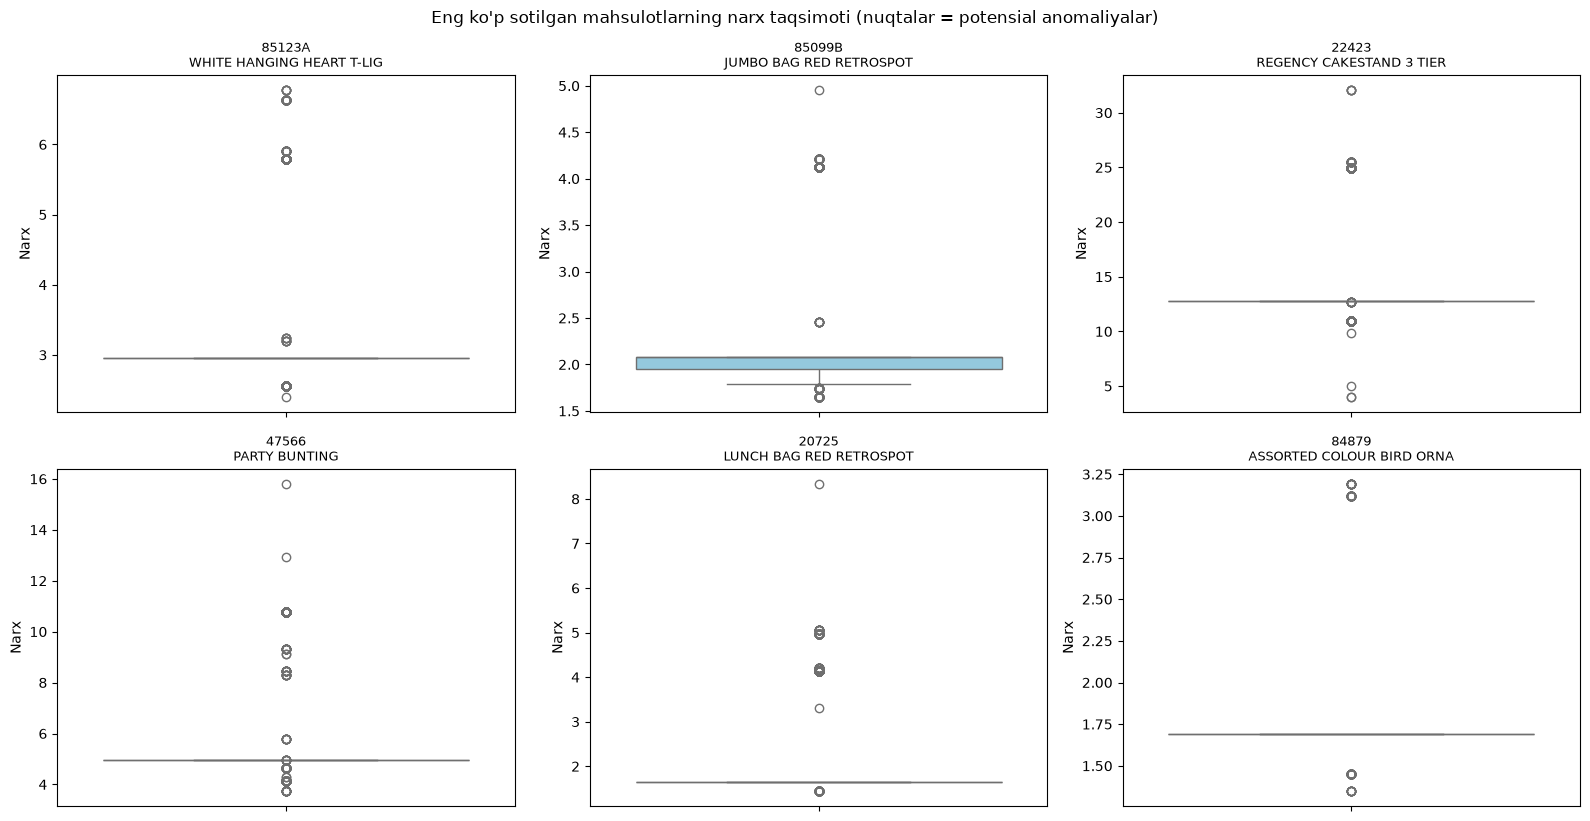

In [22]:
top_products = df_clean["StockCode"].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, code_ in enumerate(top_products):
    subset = df_clean[df_clean["StockCode"] == code_]
    desc_short = subset["Description"].iloc[0][:25]
    sns.boxplot(y=subset["UnitPrice"], ax=axes[i], color="skyblue")
    axes[i].set_title(f"{code_}\n{desc_short}", fontsize=9)
    axes[i].set_ylabel("Narx")

plt.tight_layout()
plt.suptitle("Eng ko'p sotilgan mahsulotlarning narx taqsimoti (nuqtalar = potensial anomaliyalar)", y=1.02)
plt.show()

In [23]:
def flag_row(row):
    stats = product_stats.loc[row["StockCode"]] if row["StockCode"] in product_stats.index and product_stats.loc[row["StockCode"], "count"] >= MIN_SAMPLES else None
    if stats is None:
        lower, upper = global_stats["lower_bound"], global_stats["upper_bound"]
    else:
        lower, upper = stats["lower_bound"], stats["upper_bound"]
    if row["UnitPrice"] < lower:
        return "LOW_ANOMALY"
    elif row["UnitPrice"] > upper:
        return "HIGH_ANOMALY"
    return "NORMAL"


sample = df_clean.sample(20000, random_state=42).copy()
sample["anomaly_status"] = sample.apply(flag_row, axis=1)

anomaly_summary = sample["anomaly_status"].value_counts()
print(anomaly_summary)
print(f"\nAnomaliya foizi: {(anomaly_summary.get('LOW_ANOMALY',0) + anomaly_summary.get('HIGH_ANOMALY',0)) / len(sample) * 100:.2f}%")

sample[sample["anomaly_status"] != "NORMAL"][["StockCode", "Description", "UnitPrice", "anomaly_status"]].sort_values("UnitPrice").head(15)

anomaly_status
NORMAL          17748
HIGH_ANOMALY     1944
LOW_ANOMALY       308
Name: count, dtype: int64

Anomaliya foizi: 11.26%


,StockCode,Description,UnitPrice,anomaly_status
142702,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.21,LOW_ANOMALY
111536,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.21,LOW_ANOMALY
48161,85230G,ORANGE VOTIVE CANDLE,0.21,LOW_ANOMALY
403796,17021,NAMASTE SWAGAT INCENSE,0.24,LOW_ANOMALY
506222,22581,WOOD STOCKING CHRISTMAS SCANDISPOT,0.29,LOW_ANOMALY
527069,90214Z,"LETTER ""Z"" BLING KEY RING",0.29,LOW_ANOMALY
228259,22709,WRAP WEDDING DAY,0.34,LOW_ANOMALY
140477,16156S,WRAP PINK FAIRY CAKES,0.34,LOW_ANOMALY
262455,21503,TOYBOX WRAP,0.34,LOW_ANOMALY
269297,22711,WRAP CIRCUS PARADE,0.34,LOW_ANOMALY


In [25]:
def interactive_check():
    stock_code = input("Mahsulot kodini (StockCode) kiriting: ").strip()
    try:
        entered_price = float(input("Narxni kiriting: ").strip())
    except ValueError:
        print(" Noto'g'ri narx formati!")
        return

    result = check_price(stock_code, entered_price, verbose=False)

    print()
    print("="*55)
    print(f"{'Mahsulot:':<22} {result['description']}")
    print(f"{'Kod:':<22} {result['stock_code']}")
    print("-"*55)
    print(f"{'Siz kiritgan narx:':<22} {result['entered_price']:.2f}")
    print(f"{'Odatiy (normal) narx:':<22} {result['median_price']:.2f}")
    print(f"{'Ruxsat etilgan oraliq:':<22} {result['lower_bound']:.2f} - {result['upper_bound']:.2f}")
    print("="*55)
    print(result["message"])
    print()

    return result

interactive_check()

Mahsulot kodini (StockCode) kiriting:  84077
Narxni kiriting:  o.1


 Noto'g'ri narx formati!
